## Changing Approach to Duplicates
Post-Project.

Using the Points of Interest that show up multiple times to get more information on the number of Bike Spots around Points of Interest.


In [1]:
# imports
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# importing the data
FSCRData = pd.read_csv('../data/FoursquareData.csv')
FSCRData

,Name,Category ID,Category Name,Latitude,Longitude,Distance,Popularity,Price,Rating,Description
0,Ravintola Paulette,13148,French Restaurant,60.158526,24.945557,435,0.981589,2.0,9.1,NaN
1,Kaffa Roastery,13034,Café,60.158463,24.934133,939,0.992039,2.0,9.0,NaN
2,Daddy Greens Pizzabar - Iso Roobertinkatu,13064,Pizzeria,60.162840,24.940647,984,0.981128,1.0,8.8,Daddy Greens Pizzabar is a pizzeria in Töölö a...
3,Ravintola Skiffer,13064,Pizzeria,60.152901,24.946306,354,0.967701,2.0,8.7,NaN
4,Ravintola Pastis,13148,French Restaurant,60.164127,24.947772,979,0.982049,2.0,8.6,Autenttinen maalaisranskalainen keittiö ja tun...
...,...,...,...,...,...,...,...,...,...,...
25024,Ravintola Töölö,13022,Sports Bar,60.188297,24.917887,580,0.985921,1.0,4.9,NaN
25025,Hesburger Helsinki Töölö,13145,Fast Food Restaurant,60.184169,24.924048,99,0.979148,1.0,4.9,The factors behind Hesburger’s success are tas...
25026,Neste K Eläintarha,13034,Café,60.193018,24.930322,961,0.996032,NaN,4.8,Neste K Helsinki Eläintarha on 24h palveleva l...
25027,HSL 1915 Töölön Kisahalli,19043,Bus Stop,60.184650,24.923348,119,0.989687,NaN,NaN,NaN


In [3]:
# removing values that are a further distance than the expected radius of 1000m
FSCRDataWithinRadius = pd.DataFrame(FSCRData[FSCRData['Distance'] <= 1000])
FSCRDataWithinRadius

,Name,Category ID,Category Name,Latitude,Longitude,Distance,Popularity,Price,Rating,Description
0,Ravintola Paulette,13148,French Restaurant,60.158526,24.945557,435,0.981589,2.0,9.1,NaN
1,Kaffa Roastery,13034,Café,60.158463,24.934133,939,0.992039,2.0,9.0,NaN
2,Daddy Greens Pizzabar - Iso Roobertinkatu,13064,Pizzeria,60.162840,24.940647,984,0.981128,1.0,8.8,Daddy Greens Pizzabar is a pizzeria in Töölö a...
3,Ravintola Skiffer,13064,Pizzeria,60.152901,24.946306,354,0.967701,2.0,8.7,NaN
4,Ravintola Pastis,13148,French Restaurant,60.164127,24.947772,979,0.982049,2.0,8.6,Autenttinen maalaisranskalainen keittiö ja tun...
...,...,...,...,...,...,...,...,...,...,...
25024,Ravintola Töölö,13022,Sports Bar,60.188297,24.917887,580,0.985921,1.0,4.9,NaN
25025,Hesburger Helsinki Töölö,13145,Fast Food Restaurant,60.184169,24.924048,99,0.979148,1.0,4.9,The factors behind Hesburger’s success are tas...
25026,Neste K Eläintarha,13034,Café,60.193018,24.930322,961,0.996032,NaN,4.8,Neste K Helsinki Eläintarha on 24h palveleva l...
25027,HSL 1915 Töölön Kisahalli,19043,Bus Stop,60.184650,24.923348,119,0.989687,NaN,NaN,NaN


In [4]:
# adding a counter
FSCRDataWithinRadius['Counter'] = 1

# grouping data by Points of Interest and getting a count of each Point of Interest
FSCRDataGroupedPOI = FSCRDataWithinRadius.groupby(['Name','Latitude','Longitude'])['Counter'].sum()
FSCRDataGroupedPOI

Name                                Latitude   Longitude
10 Hammas                           60.210997  25.079795     1
3Amigos                             60.293003  25.036842     1
60° Bar & Brewery                   60.316169  24.971572     1
88-Burgers                          60.228628  24.962211     6
99 Burgers                          60.228553  24.961850     9
                                                            ..
ms Koningsdam Culinary Arts Center  60.155296  24.922520     4
Ääniwalli                           60.195243  24.949869    21
Ölhus Helsinki                      60.189454  24.916251    12
Наша Дорога                         60.145671  24.909756     1
المطعم اليمني Yemeni Restaurant     60.192735  25.042747     6
Name: Counter, Length: 4610, dtype: int64

The duplicate points that show up are showing up because they showed up as a result for more than one Bike Spot. Each number in Count is the amount of Bike Spots near that particular Point of Interest.

In [5]:
# resetting index to convert the groupby object into a DataFrame
FSCRDataGroupedPOI = FSCRDataGroupedPOI.reset_index(name='Bike Spots Near')
FSCRDataGroupedPOI

,Name,Latitude,Longitude,Bike Spots Near
0,10 Hammas,60.210997,25.079795,1
1,3Amigos,60.293003,25.036842,1
2,60° Bar & Brewery,60.316169,24.971572,1
3,88-Burgers,60.228628,24.962211,6
4,99 Burgers,60.228553,24.961850,9
...,...,...,...,...
4605,ms Koningsdam Culinary Arts Center,60.155296,24.922520,4
4606,Ääniwalli,60.195243,24.949869,21
4607,Ölhus Helsinki,60.189454,24.916251,12
4608,Наша Дорога,60.145671,24.909756,1


In [6]:
# counting occurences of locations
FSCRDataFrequency = FSCRDataGroupedPOI['Bike Spots Near'].value_counts().sort_index()
FSCRDataFrequency

Bike Spots Near
1     640
2     654
3     624
4     552
5     452
6     345
7     299
8     267
9     191
10     99
11     89
12     78
13     60
14     36
15     41
16     19
17     31
18     21
19     19
20     14
21     12
22     13
23      4
24      8
25      5
26      5
27      1
28      8
29      2
30      6
31      1
32      6
33      3
34      4
35      1
Name: count, dtype: int64

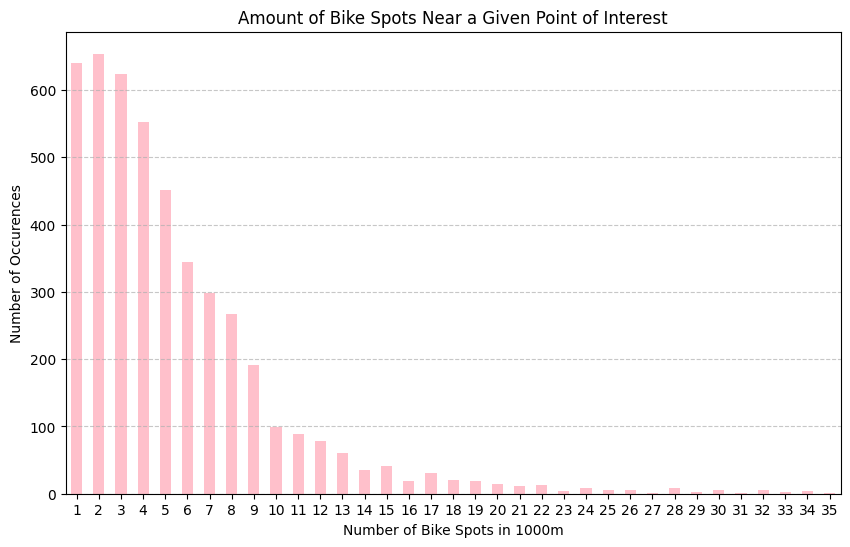

In [9]:
# plotting the frequency of Bike Spots near Points of Interest
plt.figure(figsize=(10, 6))
FSCRDataFrequency.plot(kind='bar', color='pink')
plt.title('Amount of Bike Spots Near a Given Point of Interest')
plt.xlabel('Number of Bike Spots in 1000m')
plt.ylabel('Number of Occurences')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

We can see that most of the Points of Interest are near less than 10 Bike Spots.

In [7]:
FSCRDataWithinRadius.columns

Index(['Name', 'Category ID', 'Category Name', 'Latitude', 'Longitude',
       'Distance', 'Popularity', 'Price', 'Rating', 'Description', 'Counter'],
      dtype='object')

In [15]:
# checking if duplicate POIs have different values
FSCRDataWithinRadius.duplicated(subset=['Name','Latitude','Longitude']).value_counts() == FSCRDataWithinRadius.duplicated(subset=['Name','Latitude','Longitude','Popularity']).value_counts()

True     False
False    False
Name: count, dtype: bool

In [8]:
# identifying POI with duplicates
POIDuplicates = FSCRDataWithinRadius[FSCRDataWithinRadius.duplicated(subset=['Name','Latitude','Longitude'], keep=False)]
POIDuplicates

,Name,Category ID,Category Name,Latitude,Longitude,Distance,Popularity,Price,Rating,Description,Counter
0,Ravintola Paulette,13148,French Restaurant,60.158526,24.945557,435,0.981589,2.0,9.1,NaN,1
1,Kaffa Roastery,13034,Café,60.158463,24.934133,939,0.992039,2.0,9.0,NaN,1
3,Ravintola Skiffer,13064,Pizzeria,60.152901,24.946306,354,0.967701,2.0,8.7,NaN,1
4,Ravintola Pastis,13148,French Restaurant,60.164127,24.947772,979,0.982049,2.0,8.6,Autenttinen maalaisranskalainen keittiö ja tun...,1
5,Restaurant Elm,13065,Restaurant,60.156974,24.952636,217,0.989517,NaN,8.6,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...
25024,Ravintola Töölö,13022,Sports Bar,60.188297,24.917887,580,0.985921,1.0,4.9,NaN,1
25025,Hesburger Helsinki Töölö,13145,Fast Food Restaurant,60.184169,24.924048,99,0.979148,1.0,4.9,The factors behind Hesburger’s success are tas...,1
25026,Neste K Eläintarha,13034,Café,60.193018,24.930322,961,0.996032,NaN,4.8,Neste K Helsinki Eläintarha on 24h palveleva l...,1
25027,HSL 1915 Töölön Kisahalli,19043,Bus Stop,60.184650,24.923348,119,0.989687,NaN,NaN,NaN,1


In [10]:
# identifying the differing Popularity values for duplicated POIs
PopularityDuplicates = POIDuplicates.groupby(['Name','Latitude','Longitude'])['Popularity'].nunique()

# any count greater than 1 indicates a POI with a different Popularity value
UniquePopularityValues = PopularityDuplicates[PopularityDuplicates > 1]

# identifying these rows
PopularityDifference = POIDuplicates[POIDuplicates.set_index(['Name','Latitude','Longitude']).index.isin(UniquePopularityValues.index)]
PopularityDifference

,Name,Category ID,Category Name,Latitude,Longitude,Distance,Popularity,Price,Rating,Description,Counter
4733,Espoon kaupunki Sellon kirjasto,12080,Library,60.217506,24.809773,773,0.998876,NaN,8.0,Sellon kirjasto on osa Espoon kaupunginkirjast...,1
4776,Espoon kaupunki Sellon kirjasto,12080,Library,60.217506,24.809773,773,0.066917,NaN,NaN,NaN,1
4783,Espoon kaupunki Sellon kirjasto,12080,Library,60.217506,24.809773,987,0.998876,NaN,8.0,Sellon kirjasto on osa Espoon kaupunginkirjast...,1
4834,Espoon kaupunki Sellon kirjasto,12080,Library,60.217506,24.809773,553,0.998876,NaN,8.0,Sellon kirjasto on osa Espoon kaupunginkirjast...,1
4865,Espoon kaupunki Sellon kirjasto,12080,Library,60.217506,24.809773,553,0.066917,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...
23954,HSL V5104 Veromäen koulu,19043,Bus Stop,60.286619,24.960057,816,0.935900,NaN,NaN,NaN,1
24017,HSL V5104 Veromäen koulu,19043,Bus Stop,60.286619,24.960057,580,0.698479,NaN,NaN,NaN,1
24018,HSL V5104 Veromäen koulu,19043,Bus Stop,60.286619,24.960057,580,0.935900,NaN,NaN,NaN,1
24701,HSL V5104 Veromäen koulu,19043,Bus Stop,60.286619,24.960057,998,0.698479,NaN,NaN,NaN,1


In [ ]:
# average ratings and popularity on same POI
# identify if price is given a different value for POI and decide how to handle if so

In [10]:
FSCRDataDistances = FSCRDataWithinRadius.groupby(['Name','Latitude','Longitude']).agg({'Distance': ['mean', 'min', 'max']})
FSCRDataDistances

Distance          
                                                              mean  min  max
Name                               Latitude  Longitude                      
10 Hammas                          60.210997 25.079795  997.000000  997  997
3Amigos                            60.293003 25.036842  964.000000  964  964
60° Bar & Brewery                  60.316169 24.971572  362.000000  362  362
88-Burgers                         60.228628 24.962211  776.666667  590  944
99 Burgers                         60.228553 24.961850  623.555556   98  966
...                                                            ...  ...  ...
ms Koningsdam Culinary Arts Center 60.155296 24.922520  688.500000  597  814
Ääniwalli                          60.195243 24.949869  687.714286  171  998
Ölhus Helsinki                     60.189454 24.916251  526.000000  207  856
Наша Дорога                        60.145671 24.909756  625.000000  625  625
المطعم اليمني Yemeni Restaurant    60.192735 25.042747  542.333333    9  792

[4610 rows x 3 columns]

In [41]:
# preparing the data for visualization
# flattening the multi-index columns and resetting the index
FSCRDataDistances.columns = ['_'.join(col).strip() for col in FSCRDataDistances.columns.values]
FSCRDataDistances = FSCRDataDistances.reset_index()
FSCRDataDistances

,Name,Latitude,Longitude,Distance_mean,Distance_min,Distance_max
0,10 Hammas,60.210997,25.079795,997.000000,997,997
1,3Amigos,60.293003,25.036842,964.000000,964,964
2,60° Bar & Brewery,60.316169,24.971572,362.000000,362,362
3,88-Burgers,60.228628,24.962211,776.666667,590,944
4,99 Burgers,60.228553,24.961850,623.555556,98,966
...,...,...,...,...,...,...
4605,ms Koningsdam Culinary Arts Center,60.155296,24.922520,688.500000,597,814
4606,Ääniwalli,60.195243,24.949869,687.714286,171,998
4607,Ölhus Helsinki,60.189454,24.916251,526.000000,207,856
4608,Наша Дорога,60.145671,24.909756,625.000000,625,625


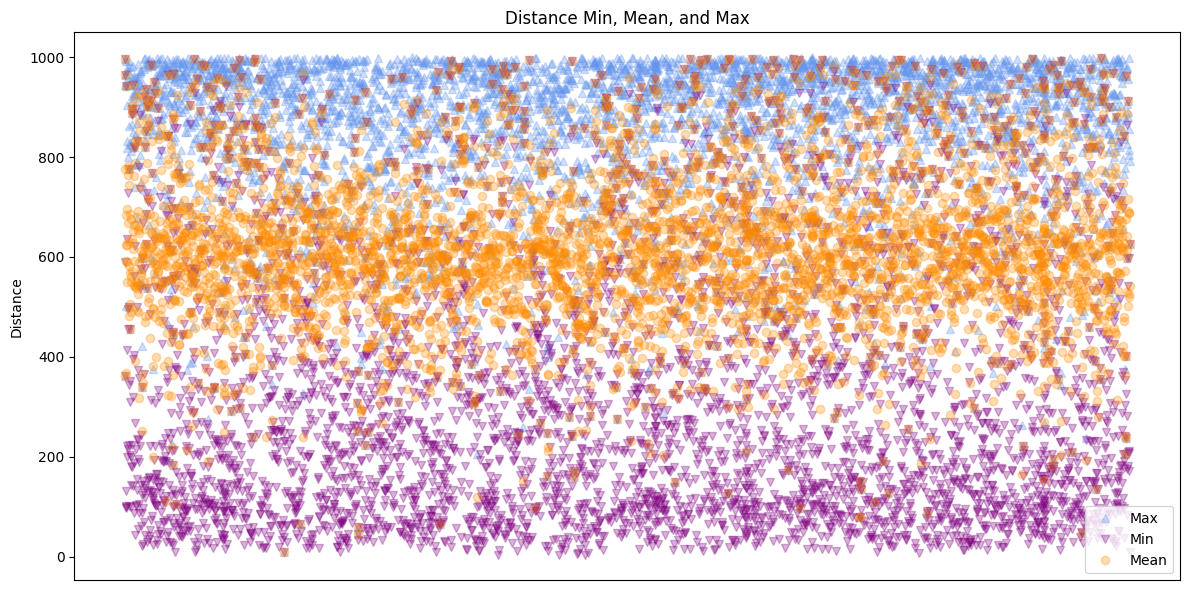

In [42]:
# visualizing the distances
plt.figure(figsize=(12, 6))
# plot Point of Interest and Distance values, no lines visible, transparent markers to see all of them
plt.plot(FSCRDataDistances['Name'], FSCRDataDistances['Distance_max'], linewidth=0, alpha = 0.3, label='Max', marker='^', color='cornflowerblue')
plt.plot(FSCRDataDistances['Name'], FSCRDataDistances['Distance_min'], linewidth=0, alpha = 0.3, label='Min', marker='v', color='purple')
plt.plot(FSCRDataDistances['Name'], FSCRDataDistances['Distance_mean'], linewidth=0, alpha = 0.3, label='Mean', marker='o', color='darkorange')
plt.ylabel('Distance')
plt.title('Distance Min, Mean, and Max')
plt.xticks([])
plt.legend()
plt.tight_layout()
plt.show()

- some locations are quite close to all the Bike Spots they are close to

In [43]:
# combining the data so we can see the distance stats and the count of Bike Spots near a POI

In [44]:
# combining the data from the API call with the calculated distance data for each Point of Interest
FSCRDataCombined = pd.merge(
    left=FSCRDataWithinRadius, 
    right=FSCRDataDistances,
    how='left',
    left_on=['Name', 'Latitude', 'Longitude'],
    right_on=['Name', 'Latitude', 'Longitude'],
)
FSCRDataCombined

,Name,Category ID,Category Name,Latitude,Longitude,Distance,Popularity,Price,Rating,Description,Counter,Distance_mean,Distance_min,Distance_max
0,Ravintola Paulette,13148,French Restaurant,60.158526,24.945557,435,0.981589,2.0,9.1,NaN,1,576.333333,51,966
1,Kaffa Roastery,13034,Café,60.158463,24.934133,939,0.992039,2.0,9.0,NaN,1,649.750000,112,939
2,Daddy Greens Pizzabar - Iso Roobertinkatu,13064,Pizzeria,60.162840,24.940647,984,0.981128,1.0,8.8,Daddy Greens Pizzabar is a pizzeria in Töölö a...,1,984.000000,984,984
3,Ravintola Skiffer,13064,Pizzeria,60.152901,24.946306,354,0.967701,2.0,8.7,NaN,1,647.333333,354,832
4,Ravintola Pastis,13148,French Restaurant,60.164127,24.947772,979,0.982049,2.0,8.6,Autenttinen maalaisranskalainen keittiö ja tun...,1,643.950000,136,991
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25014,Ravintola Töölö,13022,Sports Bar,60.188297,24.917887,580,0.985921,1.0,4.9,NaN,1,538.538462,55,983
25015,Hesburger Helsinki Töölö,13145,Fast Food Restaurant,60.184169,24.924048,99,0.979148,1.0,4.9,The factors behind Hesburger’s success are tas...,1,554.727273,99,981
25016,Neste K Eläintarha,13034,Café,60.193018,24.930322,961,0.996032,NaN,4.8,Neste K Helsinki Eläintarha on 24h palveleva l...,1,715.230769,428,993
25017,HSL 1915 Töölön Kisahalli,19043,Bus Stop,60.184650,24.923348,119,0.989687,NaN,NaN,NaN,1,393.428571,119,698


In [45]:
# combining the combined data above with the calculated counts of Bike Spots near each Point of Interest
FSCRDataStats = pd.merge(
    left=FSCRDataCombined, 
    right=FSCRDataGroupedPOI,
    how='left',
    left_on=['Name', 'Latitude', 'Longitude'],
    right_on=['Name', 'Latitude', 'Longitude'],
)
FSCRDataStats

,Name,Category ID,Category Name,Latitude,Longitude,Distance,Popularity,Price,Rating,Description,Counter,Distance_mean,Distance_min,Distance_max,Bike Spots Near
0,Ravintola Paulette,13148,French Restaurant,60.158526,24.945557,435,0.981589,2.0,9.1,NaN,1,576.333333,51,966,6
1,Kaffa Roastery,13034,Café,60.158463,24.934133,939,0.992039,2.0,9.0,NaN,1,649.750000,112,939,16
2,Daddy Greens Pizzabar - Iso Roobertinkatu,13064,Pizzeria,60.162840,24.940647,984,0.981128,1.0,8.8,Daddy Greens Pizzabar is a pizzeria in Töölö a...,1,984.000000,984,984,1
3,Ravintola Skiffer,13064,Pizzeria,60.152901,24.946306,354,0.967701,2.0,8.7,NaN,1,647.333333,354,832,3
4,Ravintola Pastis,13148,French Restaurant,60.164127,24.947772,979,0.982049,2.0,8.6,Autenttinen maalaisranskalainen keittiö ja tun...,1,643.950000,136,991,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25014,Ravintola Töölö,13022,Sports Bar,60.188297,24.917887,580,0.985921,1.0,4.9,NaN,1,538.538462,55,983,13
25015,Hesburger Helsinki Töölö,13145,Fast Food Restaurant,60.184169,24.924048,99,0.979148,1.0,4.9,The factors behind Hesburger’s success are tas...,1,554.727273,99,981,11
25016,Neste K Eläintarha,13034,Café,60.193018,24.930322,961,0.996032,NaN,4.8,Neste K Helsinki Eläintarha on 24h palveleva l...,1,715.230769,428,993,13
25017,HSL 1915 Töölön Kisahalli,19043,Bus Stop,60.184650,24.923348,119,0.989687,NaN,NaN,NaN,1,393.428571,119,698,7


In [46]:
# removing the 'Counter' and 'Description' columns for not having useful data at this stage
FSCRDataStats = FSCRDataStats.drop(['Counter','Description'], axis=1)
FSCRDataStats

,Name,Category ID,Category Name,Latitude,Longitude,Distance,Popularity,Price,Rating,Distance_mean,Distance_min,Distance_max,Bike Spots Near
0,Ravintola Paulette,13148,French Restaurant,60.158526,24.945557,435,0.981589,2.0,9.1,576.333333,51,966,6
1,Kaffa Roastery,13034,Café,60.158463,24.934133,939,0.992039,2.0,9.0,649.750000,112,939,16
2,Daddy Greens Pizzabar - Iso Roobertinkatu,13064,Pizzeria,60.162840,24.940647,984,0.981128,1.0,8.8,984.000000,984,984,1
3,Ravintola Skiffer,13064,Pizzeria,60.152901,24.946306,354,0.967701,2.0,8.7,647.333333,354,832,3
4,Ravintola Pastis,13148,French Restaurant,60.164127,24.947772,979,0.982049,2.0,8.6,643.950000,136,991,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25014,Ravintola Töölö,13022,Sports Bar,60.188297,24.917887,580,0.985921,1.0,4.9,538.538462,55,983,13
25015,Hesburger Helsinki Töölö,13145,Fast Food Restaurant,60.184169,24.924048,99,0.979148,1.0,4.9,554.727273,99,981,11
25016,Neste K Eläintarha,13034,Café,60.193018,24.930322,961,0.996032,NaN,4.8,715.230769,428,993,13
25017,HSL 1915 Töölön Kisahalli,19043,Bus Stop,60.184650,24.923348,119,0.989687,NaN,NaN,393.428571,119,698,7
